### Housing data (regression), dataset evaluation report

Target variable is **price** (continuous, regression).

Price range is 75 000 - 7 700 000 USD, some outliers in the high-end.

<hr>

**Variables to drop or to process further**

- **id** can be dropped (no significance in this context, just an identifier field)
- **date** only contains one year of time, if used, needs to be processed by years/months/quarters etc. Since it's only one year of time, can also be dropped.
- **lat, long, zipcode** have be to considered separately, since they are spatial meta information => location of the house
    - location plays a crucial role in house market, but we have to use proper methods in order to use these variables (clustering, distance to city centre etc.)
    - using lat/long as they are is dangerous, because they look like conventional measurements to a ML model, but they are actually coordinates

**Rest of the variables**

- bedrooms
- bathrooms
- sqft_living
- sqft_lot
- floors
- waterfront
- view
- condition
- grade
- sqft_above
- sqft_basement
- yr_built
- yr_renovated
- sqft_lot15

<hr>

**Variable importance and redundancy analysis**

**price** is highly correlated with **grade, sqft_living, sqft_living15 and sqft_above**. (Source: y-data-report). 

**bathrooms** also seem to have a connection to **price**, where as **view** and **floors** seem to have a milder connection.

There might be redundancy in the sqft_columns. For example, **sqft_living = sqft_above + sqft_basement**. This means we have derived variables regarding square footage, containing possibly a considertable amount of redundancy.

**VIF-test for multicollinearity**

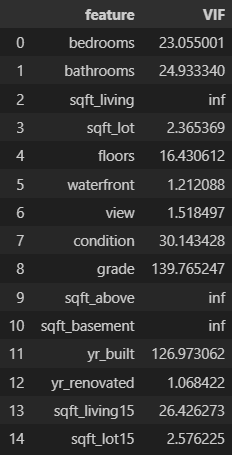

We can see in the VIF-test: **sqft_living, sqft_above and sqft_basement** have positive infinite VIF-test score, implying extreme multicollinearity and redundancy. Few options we can try with these variables:

- Option 1: remove sqft_living and preserve sqft_above and sqft_basement
- Option 2: change sqft_basement to boolean category: (has basement, no basement - 1/0), and remove one of the other variables

<hr>

**Data imbalances**

Variables **waterfront** amd **view** are extremely imbalanced (one-sided). 

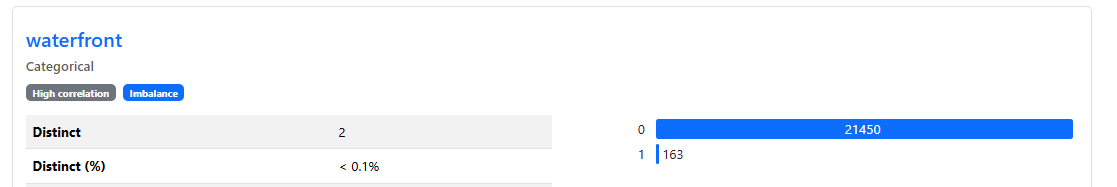

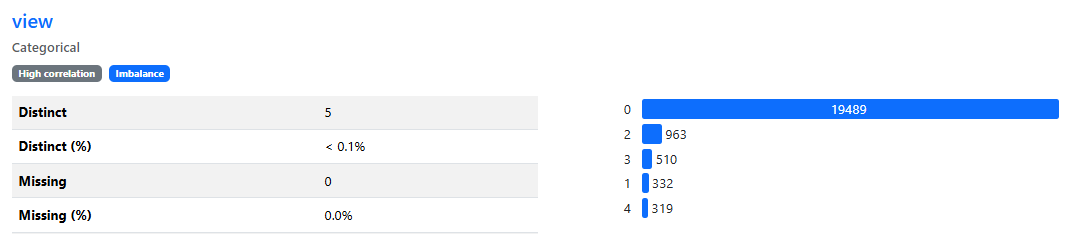

Things to consider for waterfront/view: 

- Approach 1: Under-/oversampling techniques + synthesize more data (CTGAN, CopulaSynthesizer etc)
    - However, the imbalance is so extreme, we might need to consider other options
- Approach 2: We could combine waterfront and view into a single variable, but then again, distributions are so imbalanced, they are almost like outliers (most houses have a bad view), or maybe convert these variables into boolean variables

**sqft_basement and yr_renovated**

**yr_renovated** has a high number of zeroes (~96%). Ideas to try in future:
- combine yr_built and yr_renovated => yr_built_or_last_renovation. The idea is to have the latest year in one column when any kind of construction work was done in this house.

**sqft_basement** has over 60% zero values, indicates many of the houses don't have a basement. Ideas to try:

- convert sqft_basement into a categorical binned variable -> no basement, small basement, average basement, large basement
    - however, boolean variable (no basement/has basement) is probably the best conversion, due to majority of houses not having a basement

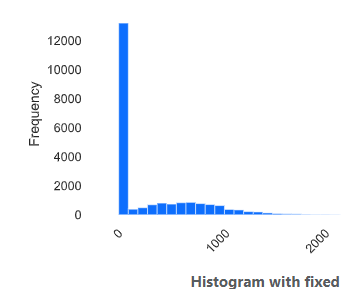

If using **yr_built** either directly or combined with **yr_renovated** => there's a small balance issue in the ataset => more newer than older buildings in the dataset. This is probably natural, since older houses often have to be demolished.

There's also a small gap in 1929 onwards => probably The Great Depression. (due to economy reasons, only few buildings were made.)

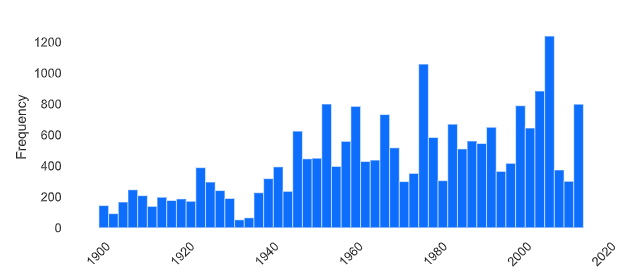

___

**Distributions**

___

**Overall trends and irregularities**

___

### Summary of key points:

In [ ]:
# TODO: study redundancy with VIF-test (multicollinearity)